<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


In [ ]:
# Load dataset
data = pd.read_csv("creditcard.csv")

# Handle missing values
data = data.fillna(data.mean())

# Encode categorical columns if needed
for col in data.select_dtypes(include=['object']).columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# Features & target
X = data.drop("Class", axis=1).values
y = data["Class"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)


Epoch 1/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9789 - loss: 0.0539

5697/5697 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9958 - loss: 0.0141 - val_accuracy: 0.9993 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 2/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9993 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 3/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9993 - loss: 0.0038 - val_accuracy: 0.9994 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 4/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 5/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0045 - learning_rate: 5.0000e-04
Epoch 6/50
5694/5697 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - loss: 0.0029

5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Epoch 7/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0041 - learning_rate: 5.0000e-04
Epoch 8/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9993 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0051 - learning_rate: 5.0000e-04
Epoch 9/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9994 - val_loss: 0.0042 - learning_rate: 5.0000e-04
Epoch 10/50
5686/5697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9994 - loss: 0.0026

5697/5697 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9994 - val_loss: 0.0033 - learning_rate: 2.5000e-04
Epoch 11/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9994 - val_loss: 0.0041 - learning_rate: 2.5000e-04
Epoch 12/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9994 - val_loss: 0.0038 - learning_rate: 2.5000e-04
Epoch 13/50
5683/5697 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - loss: 0.0024

5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9994 - val_loss: 0.0031 - learning_rate: 2.5000e-04
Epoch 14/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9994 - val_loss: 0.0034 - learning_rate: 2.5000e-04
Epoch 15/50
5693/5697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0022

5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0029 - learning_rate: 2.5000e-04
Epoch 16/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0039 - learning_rate: 2.5000e-04
Epoch 17/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0034 - learning_rate: 2.5000e-04
Epoch 18/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0033 - learning_rate: 2.5000e-04
Epoch 19/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0033 - learning_rate: 1.2500e-04
Epoch 20/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0031 - learning_rate: 1.2500e-04


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9994 - loss: 0.0031
Test Accuracy: 1.00
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



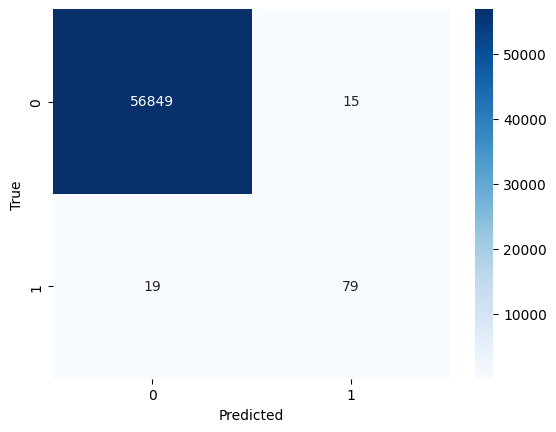

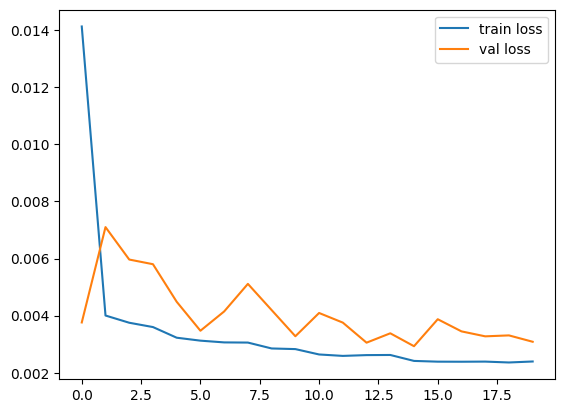

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Training curves
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()


In [ ]:
reg_model = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Linear output for regression
])

reg_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
reg_history = reg_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)


Epoch 1/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0193 - mae: 0.0571 - val_loss: 0.0101 - val_mae: 0.0106 - learning_rate: 0.0010
Epoch 2/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 7.5455e-04 - mae: 0.0063 - val_loss: 0.0383 - val_mae: 0.0084 - learning_rate: 0.0010
Epoch 3/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.5418e-04 - mae: 0.0029 - val_loss: 0.0256 - val_mae: 0.0075 - learning_rate: 0.0010
Epoch 4/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 5.9934e-04 - mae: 0.0017 - val_loss: 0.0389 - val_mae: 0.0078 - learning_rate: 5.0000e-04
Epoch 5/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 6.1089e-04 - mae: 0.0017 - val_loss: 0.0211 - val_mae: 0.0061 - learning_rate: 5.0000e-04


In [ ]:
loss, mae = reg_model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.2f}")

# Predictions
y_pred = reg_model.predict(X_test)

# Calculate R²
from sklearn.metrics import r2_score
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0089 - mae: 0.0103
Test MAE: 0.01
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
R² Score: -4.21


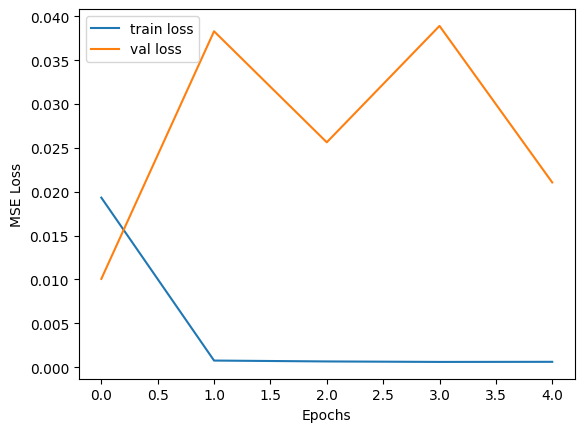

In [ ]:
plt.plot(reg_history.history['loss'], label='train loss')
plt.plot(reg_history.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


In [ ]:
target = "Class"

# Check target type
y = data[target].values

if pd.api.types.is_numeric_dtype(data[target]):
    # If numeric but few unique values, treat as classification
    if len(np.unique(y)) < 20:
        task_type = "classification"
    else:
        task_type = "regression"
else:
    task_type = "classification"

print("Detected task type:", task_type)

Detected task type: classification


In [ ]:
def build_model(task_type, input_dim, num_classes=None):
    model = Sequential([
        tf.keras.Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu')
    ])

    if task_type == "classification":
        if num_classes == 2:
            model.add(Dense(1, activation='sigmoid'))
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        else:
            model.add(Dense(num_classes, activation='softmax'))
            model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    else:  # regression
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

In [ ]:
if task_type == "classification":
    num_classes = len(np.unique(y))
    model = build_model(task_type, X_train.shape[1], num_classes)
else:
    model = build_model(task_type, X_train.shape[1])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

# Evaluation
if task_type == "classification":
    loss, acc = model.evaluate(X_test, y_test)
    print(f"Test Accuracy: {acc:.2f}")
else:
    loss, mae = model.evaluate(X_test, y_test)
    print(f"Test MAE: {mae:.2f}")


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5697/5697 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9991 - loss: 0.0065 - val_accuracy: 0.9993 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 2/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9993 - loss: 0.0041 - val_accuracy: 0.9994 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 3/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9994 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 4/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9993 - loss: 0.0035 - val_accuracy: 0.9994 - val_loss: 0.0036 - learning_rate: 5.0000e-04
Epoch 5/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0037 - learning_rate: 5.0000e-04
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9993 - loss: 0.0051
Test Accuracy: 1.00


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.77      0.79        98

    accuracy                           1.00     56962
   macro avg       0.90      0.88      0.89     56962
weighted avg       1.00      1.00      1.00     56962



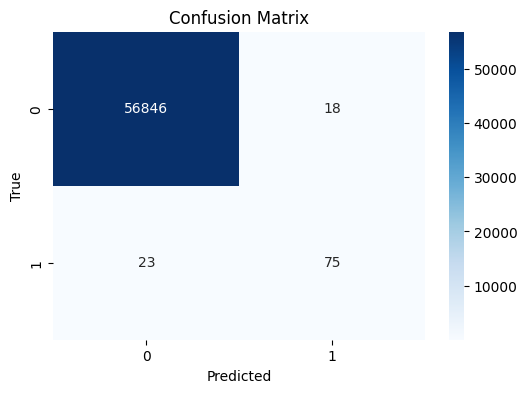

In [ ]:
if task_type == "classification":
    y_pred = (model.predict(X_test) > 0.5).astype("int32") if num_classes == 2 else np.argmax(model.predict(X_test), axis=1)

    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


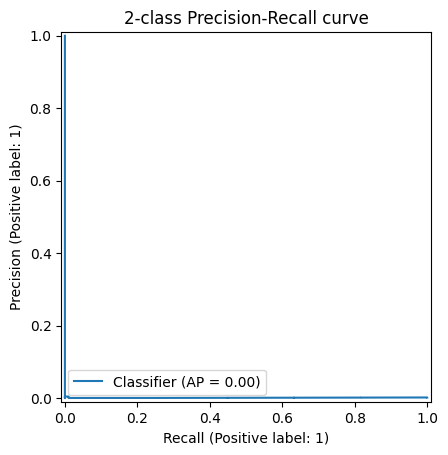

In [ ]:
if task_type == 'classification':
    y_score = model.predict(X_test)
    display = PrecisionRecallDisplay.from_predictions(y_test, y_score)
    _ = display.ax_.set_title('2-class Precision-Recall curve')
    plt.show()

In [ ]:
from sklearn.metrics import auc

if task_type == 'classification':
    # The 'display' object from the previous cell contains precision and recall
    pr_auc = auc(display.recall, display.precision)
    print(f"Area Under the Precision-Recall Curve (AUPRC): {pr_auc:.2f}")

Area Under the Precision-Recall Curve (AUPRC): 0.00


In [ ]:
if task_type == "regression":
    y_pred = model.predict(X_test)

    # Scatter plot
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Predicted vs Actual")
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # perfect fit line
    plt.show()

    # Residuals
    residuals = y_test - y_pred.flatten()
    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=30, edgecolor='black')
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Residuals Distribution")
    plt.show()


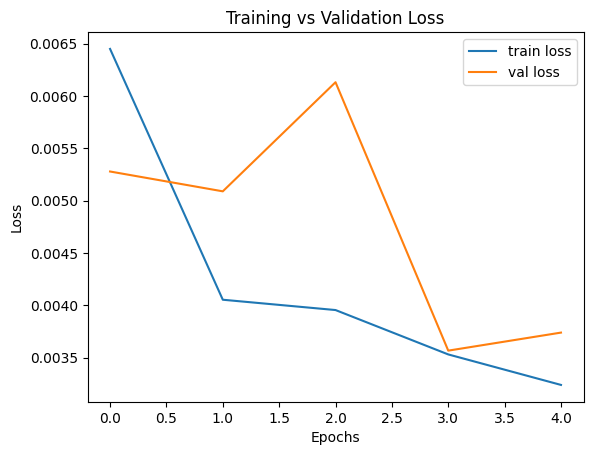

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [ ]:
def run_pipeline(data, target_column, epochs=50, batch_size=32):
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.metrics import classification_report, confusion_matrix, r2_score
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

    # --- Preprocessing ---
    df = data.copy()
    df = df.fillna(df.mean())
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = LabelEncoder().fit_transform(df[col])

    X = df.drop(target_column, axis=1).values
    y = df[target_column].values

    # Detect task type
    if pd.api.types.is_numeric_dtype(df[target_column]):
        task_type = "classification" if len(np.unique(y)) < 20 else "regression"
    else:
        task_type = "classification"
    print("Detected task type:", task_type)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # --- Build Model ---
    model = Sequential([
        tf.keras.Input(shape=(X_train.shape[1],)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu')
    ])

    if task_type == "classification":
        num_classes = len(np.unique(y))
        if num_classes == 2:
            model.add(Dense(1, activation='sigmoid'))
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        else:
            model.add(Dense(num_classes, activation='softmax'))
            model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    else:
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # --- Callbacks ---
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", save_best_only=True), # Changed from .h5 to .keras
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ]

    # --- Train ---
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=0
    )

    # --- Evaluate ---
    if task_type == "classification":
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Accuracy: {acc:.2f}")
        y_pred = (model.predict(X_test) > 0.5).astype("int32") if num_classes == 2 else np.argmax(model.predict(X_test), axis=1)
        print(classification_report(y_test, y_pred))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title("Confusion Matrix")
        plt.show()
    else:
        loss, mae = model.evaluate(X_test, y_test, verbose=0)
        print(f"Test MAE: {mae:.2f}")
        y_pred = model.predict(X_test)
        print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
        plt.scatter(y_test, y_pred, alpha=0.6)
        plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title("Predicted vs Actual")
        plt.show()
        residuals = y_test - y_pred.flatten()
        plt.hist(residuals, bins=30, edgecolor='black')
        plt.title("Residuals Distribution")
        plt.show()

    # --- Training Curves ---
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.legend()
    plt.title("Training vs Validation Loss")
    plt.show()

    return model

Detected task type: classification


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 1.00
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.74      0.78        98

    accuracy                           1.00     56962
   macro avg       0.91      0.87      0.89     56962
weighted avg       1.00      1.00      1.00     56962



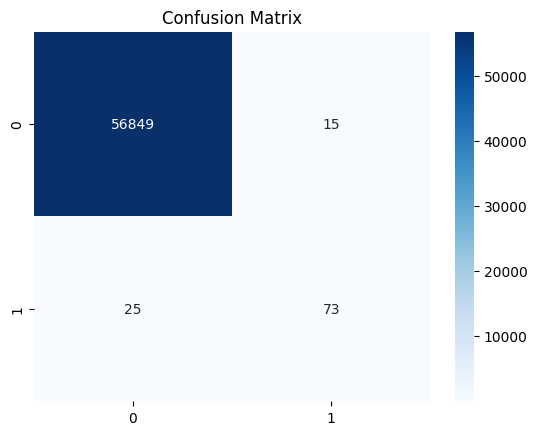

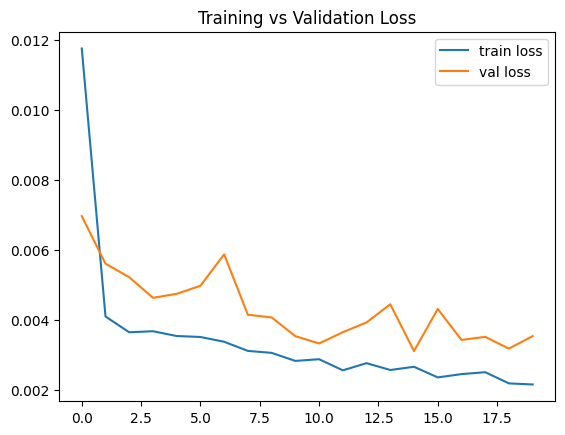

In [ ]:
# Example usage
model = run_pipeline(data, "Class")